# Model Calibration

Calibration is the process of ensuring that the predicted probabilities from a model align well with the actual probabilities in the real world

If a classification model outputs a probability of 0.80 for an event occurring, it should mean that on average the event occurs 80% of the time when the model predicts 0.8.  If this is not the case then the model is miscalibrated. 

- For 100 customers, the prediction is 0.7 for churn
- So we expect out of this 100, about 70 customers should actually churn.
- If 80 got churn then it was underestimation
- If 50 got churn then it was over estimation

# Steps in Model Calibration

- Train the model on the training set.
- Get predictions (probabilities) on the validation/calibration set.
- Fit the calibration method (Platt scaling, isotonic regression) on:
    - inputs: predicted probabilities
    - targets: actual labels
    - Apply the learned calibration function to the validation set (for checking) the test set (final evaluation) any future unseen data

# Brier Score Loss

Measures mean squared error between predicted probability and the actual label

Overconfident wrong predictions → Higher Brier Score 

$$
\text{Brier Score = Reliability - (Resolution + Uncertainty)}
$$

$$
\text{Brier} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2
$$

$$
\text{Calibration Error / Reliability} =  \sum_{b=1}^{B} \frac{n_b}{N} (p_b - \bar{y}_b)^2
$$

$$
\text{Resolution/Discrimination} =  \sum_{b=1}^{B} \frac{n_b}{N} ( \bar{y}_b - \bar{y})^2 
$$

$$
\text{Uncertainty} = \bar{y} ( 1- \bar{y}) 
$$

- Resolution checks if the observed proportion differs from the average proportion.
- Reliability checks if average predicted probability matches the actual proportion in that bin.

- If calibration curve
    - Above diagonal → Under Confident
    - Below diagonal → Over Confident

**Making calibrated probabilities using Platt Scaling**

Given the uncalibrated probabilities from my model and the true target labels, I can train a logistic regression on these probabilities to learn the coefficients A and B, and then use the learned sigmoid function 

$$
P_{\text{calibrated}} = \frac{1}{1+\exp{(Af+B)}}
$$

to transform the uncalibrated probabilities into calibrated probabilities.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def compute_reliability_resolution_error(y_true, prob_pred, bins=10):
    bin_ids = np.floor(prob_pred * bins).astype(int)
    bin_ids = np.clip(bin_ids, 0, bins - 1)

    reliability = 0
    resolution = 0
    error = 0
    
    p_avg = np.mean(y_true)

    for b in range(bins):
        mask = bin_ids == b
        if np.sum(mask) == 0:
            continue
        p_bin = np.mean(y_true[mask])
        forecast_bin = np.mean(prob_pred[mask])
        weight = np.sum(mask) / len(y_true)

        reliability += weight * (p_bin - forecast_bin)**2
        resolution += weight * (p_bin - p_avg)**2

    error = reliability - resolution + p_avg * (1 - p_avg)
    return reliability, resolution, error


def plot_calibration_diagram(y_true, prob_pred, label):
    frac_pos, mean_pred = calibration_curve(y_true, prob_pred, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=label)
    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title("Calibration Curve")
    plt.grid(True)
    plt.legend()

# ---------------------------------------------------------------------------
# Step 1: Generate Data
# ---------------------------------------------------------------------------

X, y = make_classification(
    n_samples=5000, n_features=20, 
    n_informative=10, n_redundant=5, 
    random_state=42
)

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# ---------------------------------------------------------------------------
# Step 2: Train Random Forest
# ---------------------------------------------------------------------------

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
val_probs = rf.predict_proba(X_val)[:, 1]
test_probs = rf.predict_proba(X_test)[:, 1]
train_probs = rf.predict_proba(X_train)[:,1]

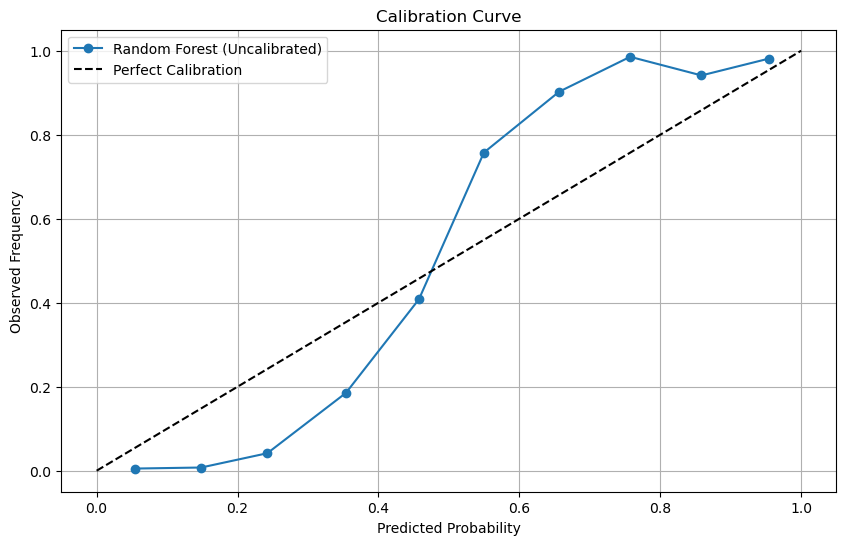

In [18]:
# ---------------------------------------------------------------------------
# Step 3: Plot calibration (uncalibrated)
# ---------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plot_calibration_diagram(y_val, val_probs, "Random Forest (Uncalibrated)")
plt.show()

brier_before = brier_score_loss(y_val, val_probs)
rel_b, res_b, err_b = compute_reliability_resolution_error(y_val, val_probs)

In [19]:
print("=== Random Forest Metrics (Before Calibration) ===")
print(f"Brier Score: {brier_before:.4f}")
print(f"Reliability: {rel_b:.4f}")
print(f"Resolution : {res_b:.4f}")
print(f"Error      : {err_b:.4f}")

=== Random Forest Metrics (Before Calibration) ===
Brier Score: 0.0633
Reliability: 0.0168
Resolution : 0.2027
Error      : 0.0640


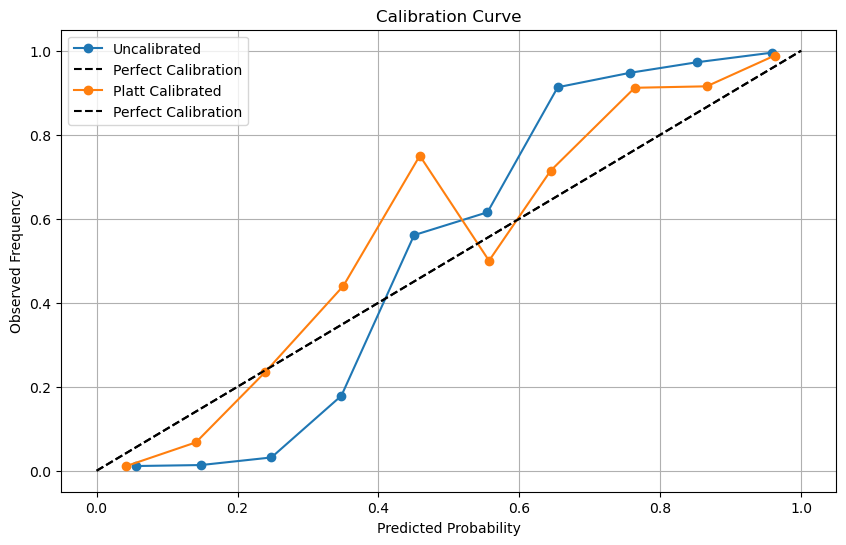

In [20]:
# ---------------------------------------------------------------------------
# Step 4: Platt Scaling using VALIDATION SET
# ---------------------------------------------------------------------------

platt = LogisticRegression(max_iter=500)
platt.fit(val_probs.reshape(-1, 1), y_val)

# Apply calibration to test predictions
platt_probs = platt.predict_proba(test_probs.reshape(-1, 1))[:, 1]

# ---------------------------------------------------------------------------
# Step 5: Plot calibration after Platt Scaling
# ---------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plot_calibration_diagram(y_test, test_probs, "Uncalibrated")
plot_calibration_diagram(y_test, platt_probs, "Platt Calibrated")
plt.show()

In [21]:
brier_after = brier_score_loss(y_test, platt_probs)
rel_a, res_a, err_a = compute_reliability_resolution_error(y_test, platt_probs)

print("\n=== Random Forest Metrics (After Platt Calibration) ===")
print(f"Brier Score: {brier_after:.4f}")
print(f"Reliability: {rel_a:.4f}")
print(f"Resolution : {res_a:.4f}")
print(f"Error      : {err_a:.4f}")


=== Random Forest Metrics (After Platt Calibration) ===
Brier Score: 0.0472
Reliability: 0.0036
Resolution : 0.2060
Error      : 0.0475


# Platt Scaling or Isotonic Regression

**Platt scaling** and **isotonic regression** are techniques to calibrate machine learning model probabilities. Platt scaling fits a sigmoid function (effective for SVMs/small data), while isotonic regression fits a non-parametric, monotonic function (better for large data/complex distortions, but prone to overfitting). 
Key Differences and Selection Criteria 
- Platt Scaling (Logistic Calibration): 
     - Best for: Small calibration datasets (&lt; 1000 samples). 
     - Method: Fits a logistic regression model (sigmoid curve) to the predicted scores. 
     - Pros: Less prone to overfitting, works well when the distortion is sigmoid-shaped (e.g., SVMs, boosted trees). 
     - Cons: Limited to monotonic, sigmoid-shaped corrections. 
- Isotonic Regression: 
     - Best for: Large calibration datasets (&gt; 1000 samples). 
     - Method: Fits a non-decreasing, free-form, piecewise-constant function (non-parametric). 
     - Pros: More powerful, can correct any monotonic distortion. 
     - Cons: Prone to overfitting on small data. 

When to Use Which? 
 * Use Platt Scaling if your dataset is small or you have limited, high-confidence prior knowledge that the error is sigmoidal. 
 * Use Isotonic Regression if you have a large dataset, which helps prevent it from fitting noise (overfitting).

# Isotonic Regression

Isotonic regression is used when you believe:
 - as x increases, y should not decrease.
 - Higher dosage → higher (or no-worse) effect
 - Higher hours studied → higher score
 - Larger sample size → equal or better accuracy
 - A risk score → non-decreasing probability
 - In real data, noise may break monotonicity (y sometimes goes down when x goes up).
 - Isotonic regression fixes that noise.

## 1. Why We Need Isotonic Regression

- Used when we know or assume the true relationship between variables should be **monotonic** (non-decreasing).
- Real data may violate monotonicity due to noise.
- Isotonic regression produces a **monotone, smoothed fit** that stays close to the original data.

**Typical use cases:**
- Machine learning probability calibration.
- Dose–response relationships in biology/medicine.
- Economics (price vs. demand).
- Any setting where monotonicity is known to hold.

## 2. What Isotonic Regression Does

- Given sorted data points  
  $$ (x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n), \quad x_1 \le x_2 \le \cdots \le x_n $$
- Find fitted values  
  $$ \hat{y}_1, \hat{y}_2, \ldots, \hat{y}_n $$
- That satisfy the **monotonicity constraint**  
  $$ \hat{y}_1 \le \hat{y}_2 \le \cdots \le \hat{y}_n $$
- And minimize squared error  
  $$ \min_{\hat{y}} \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$

## Block Averaging (Key Idea)

- If a block \( B \) of consecutive points must share the same fitted value, the optimal value is  
  $$ \hat{y}_B = \frac{1}{|B|} \sum_{i \in B} y_i $$

- In weighted form (optional):  
  $$ \hat{y}_B = \frac{\sum_{i \in B} w_i y_i}{\sum_{i \in B} w_i} $$

## Pool-Adjacent-Violators (PAV) Algorithm

- **Step 1 — Initialization**
  - Treat each point as its own block.
  - Block \( B_i = \{i\} \), value \( v_i = y_i \), weight \( w_i = 1 \).

- **Step 2 — Scan left to right**
  - For adjacent blocks \( B_i, B_{i+1} \):
    - If \( v_i \le v_{i+1} \), continue.
    - If \( v_i > v_{i+1} \), a **violation** occurs → merge blocks.

- **Step 3 — Merge Violating Blocks**
  - New block weight:  
    $$ w = w_i + w_{i+1} $$
  - New block value:  
    $$ v = \frac{w_i v_i + w_{i+1} v_{i+1}}{w_i + w_{i+1}} $$

- **Step 4 — Backward Check**
  - After merging, check previous block.
  - If previous block value > new block value → merge again.
  - Repeat until monotonicity is restored.

- **Step 5 — Form Final Fitted Values**
  - Each block produces constant fitted values:  
    $$ \hat{y}_i = \hat{y}_{i+1} = \cdots = \hat{y}_j = v_B \quad \text{for block } B = \{i,\ldots,j\} $$


## Interpretation

- Output is a **piecewise-constant, non-decreasing function**.
- It removes random decreases in data while staying close to observations.
- The final fit is the **closest possible monotone sequence** to the original data in squared-error sense.
